# NB02 — Validació de `CryptoMarketEnv` amb dense rewards

Validació completa de l'entorn `CryptoMarketEnv` usant dades reals de Kraken BTC/USD.

## Diferències clau: Dense vs Sparse rewards

**Dense rewards** (aquest entorn - `CryptoMarketEnv`):
- Reward **per-step** amb múltiples components:
  - `r_pnl`: log-return de l'equity a cada pas
  - `r_cost`: penalització per fees (trading + rollover)
  - `r_sortino`: component de Sortino ratio (opcional, `w_sortino`)
  - `r_dd`: penalització per drawdown (opcional, `w_dd`)
  - `r_hold`: penalització per HOLD en FLAT (per defecte -0.00002)
  - `r_realize`: bonus de realització al CLOSE (opcional, `realize_bonus`)
- Paràmetres de configuració: `w_pnl`, `w_sortino`, `w_cost`, `w_dd`, `realize_bonus`, etc.
- Permet modelar risc i cost de forma granular a cada pas

**Sparse rewards** (`CryptoMarketEnvConsolidatedReward` - per comparació):
- Reward = 0.0 durant HOLD dins de posicions LONG/SHORT
- Reward = `log(equity_close / equity_entry)` **només al CLOSE**
- Només 2 components: PnL consolidat al CLOSE + `hold_penalty` en FLAT
- Sense paràmetres de pesos — arquitectura minimal
- Avaluació holística de trades complets

## Taula de continguts
1. Càrrega de dades reals via DataManager
2. Validació dels espais (observació + accions)
3. Tests deterministes dense rewards
4. Tests específics dense rewards
5. Smoke tests i multi-split
6. Fee Curriculum
7. Logging i visualitzacions

In [29]:
# =============================================================================
# CEL·LA 1 — IMPORTS
# =============================================================================

import json
import random
import warnings
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from gymnasium.utils.env_checker import check_env

# ── Import de l'entorn DENSE i utilitats des de src/ ───────────────────────
from src.data.manager import DataManager
from src.rl.envs.crypto_market_env import (
    CryptoMarketEnv,
    make_env,
    PositionSide,
    LOG_COLS,
    steps_per_4h_for,
    TAKER_FEE,
    MAKER_FEE,
    MARGIN_OPENING_LONG,
    MARGIN_OPENING_SHORT,
    ROLLOVER_LONG_4H,
    ROLLOVER_SHORT_4H,
    MAX_LEVERAGE,
    STEPS_PER_4H,
    INITIAL_BALANCE,
    MAX_EPISODE_STEPS,
    MIN_EPISODE_STEPS,
    HOLD_PENALTY,
    DD_THRESHOLD,
    DD_PENALTY,
    OPEN_POSITION_PENALTY,
)
from src.rl.metrics import compute_sharpe, compute_max_drawdown
from src.rl.utils import fee_curriculum_factor

warnings.filterwarnings("ignore")
print("Imports OK")
print(f"CryptoMarketEnv: {CryptoMarketEnv}")

Imports OK
CryptoMarketEnv: <class 'src.rl.envs.crypto_market_env.CryptoMarketEnv'>


In [30]:
# =============================================================================
# CEL·LA 2 — CONFIGURACIÓ: SEEDS, PATHS I CONSTANTS
# =============================================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

import os as _os
_cwd = Path.cwd()
if not (_cwd / "data" / "processed").exists():
    _root = _cwd.parents[1]
    if (_root / "data" / "processed").exists():
        _os.chdir(_root)
        print(f"CWD canviat a: {_root}")
    else:
        print(f"AVIS: no s'ha trobat data/processed/. CWD: {_cwd}")
else:
    print(f"CWD: {Path.cwd()}")

RESULTS_DIR = Path("results_dense") / "02_environment_dense_tests"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TIMEFRAME = "60m"
PROJECT   = "nb02_env_dense"

# Passos per 4h calculats automàticament pel timeframe configurat
STEPS_PER_4H = steps_per_4h_for(TIMEFRAME)

print(f"Config OK | Timeframe: {TIMEFRAME} | SEED: {SEED}")
print(f"Fees: taker={TAKER_FEE:.4f}, maker={MAKER_FEE:.4f}, margin_long={MARGIN_OPENING_LONG:.5f}")
print(f"Rollover long: {ROLLOVER_LONG_4H:.5f} | Steps per 4h ({TIMEFRAME}): {STEPS_PER_4H}")
print(f"\n** DENSE REWARDS MODE: per-step rewards (r_pnl + r_cost + r_sortino + r_dd + r_hold + r_realize) **")

Device: cuda
CWD: c:\Users\Xavier\S9_M2.981 - TFM\00_Documentacio\Activitats\Modul_3\quant_rl_trader
Config OK | Timeframe: 60m | SEED: 42
Fees: taker=0.0040, maker=0.0025, margin_long=0.00025
Rollover long: 0.00025 | Steps per 4h (60m): 4

** DENSE REWARDS MODE: per-step rewards (r_pnl + r_cost + r_sortino + r_dd + r_hold + r_realize) **


## 1. Càrrega de dades reals via DataManager

In [31]:
# =============================================================================
# CEL·LA 4 — CÀRREGA DE DADES REALS
# =============================================================================

dm = DataManager(interval=TIMEFRAME, project_root=Path("."))
df_train, df_val, df_test = dm.load_all()
FEATURE_COLS = dm.features
N_FEATURES   = len(FEATURE_COLS)

print(f"Train: {len(df_train):>8,} files  ({df_train['timestamp'].min()} -> {df_train['timestamp'].max()})")
print(f"Val:   {len(df_val):>8,} files  ({df_val['timestamp'].min()} -> {df_val['timestamp'].max()})")
print(f"Test:  {len(df_test):>8,} files  ({df_test['timestamp'].min()} -> {df_test['timestamp'].max()})")
print()
print(f"Columnes: {len(df_train.columns)} (1 timestamp + 4 OHLC + {N_FEATURES} Norm_*)")

null_count = df_train.select(FEATURE_COLS).null_count().sum_horizontal()[0]
assert null_count == 0, f"Hi ha {null_count} NaN a les features de train!"
print(f"NaN a features de train: 0 (OK)")

Train:   43,763 files  (2018-01-01 00:00:00 -> 2022-12-31 23:00:00)
Val:      8,759 files  (2023-01-01 00:00:00 -> 2023-12-31 23:00:00)
Test:    17,500 files  (2024-01-01 00:00:00 -> 2025-12-31 00:00:00)

Columnes: 70 (1 timestamp + 4 OHLC + 65 Norm_*)
NaN a features de train: 0 (OK)


In [32]:
# =============================================================================
# CEL·LA 5 — DEFINICIÓ DE FUNCIONS: _MAKE_ENV_DENSE
# =============================================================================

def _make_env_dense(df, **kwargs):
    """Wrapper local de make_env amb FEATURE_COLS del projecte."""
    return make_env(df=df, feature_cols=FEATURE_COLS, timeframe=TIMEFRAME, **kwargs)

print(f"_make_env_dense definit (FEATURE_COLS={N_FEATURES}, TIMEFRAME={TIMEFRAME!r})")
print(f"Factory function: make_env (DENSE REWARDS)")

_make_env_dense definit (FEATURE_COLS=65, TIMEFRAME='60m')
Factory function: make_env (DENSE REWARDS)


## 2. Validació dels espais (observació + accions)

In [33]:
# =============================================================================
# CEL·LA 7 — TEST 1: Espais d'observació i accions
# =============================================================================

env_check = _make_env_dense(df_train)
obs, info = env_check.reset(seed=SEED)

OBS_DIM   = env_check.observation_space.shape[0]
N_ACTIONS = env_check.action_space.n

print(f"Observation space: {env_check.observation_space}")
print(f"Action space:      {env_check.action_space}")
print(f"Obs dim:           {OBS_DIM}  ({N_FEATURES} features + {OBS_DIM - N_FEATURES} estat intern)")
print(f"Equity inicial:    ${info['equity']:,.2f}")
print(f"Info keys:         {list(info.keys())}")
print()

assert obs.shape == (OBS_DIM,),              f"obs.shape={obs.shape} != ({OBS_DIM},)"
assert N_ACTIONS == 4,                        f"N_ACTIONS={N_ACTIONS} != 4"
assert OBS_DIM == N_FEATURES + 6,            f"OBS_DIM={OBS_DIM} != {N_FEATURES + 6}"
assert abs(info['equity'] - INITIAL_BALANCE) < 1e-6
assert info['pos_side'] == 0
assert 'n_trades' in info and 'cum_fees' in info and 'current_price' in info
print("TEST 1: PASS")

Observation space: Box(-inf, inf, (71,), float32)
Action space:      Discrete(4)
Obs dim:           71  (65 features + 6 estat intern)
Equity inicial:    $10,000.00
Info keys:         ['equity', 'cash', 'pos_qty', 'pos_side', 'fee_step', 'cum_fees', 'cum_trading_fees', 'cum_margin_fees', 'n_trades', 'realized_pnl', 'step', 'current_price']

TEST 1: PASS


In [34]:
# =============================================================================
# CEL·LA 8 — TEST 2: check_env (Gymnasium)
# =============================================================================

env_gym = _make_env_dense(df_train)
check_env(env_gym.unwrapped, skip_render_check=True)
print("check_env: PASS")

check_env: PASS


## 3. Tests deterministes amb dense rewards

In [35]:
# =============================================================================
# CEL·LA 10 — SLICES FIXOS (deterministes)
# =============================================================================

SLICE_N = 120   # mínim per tenir STEPS_PER_4H passos dins el slice

sl_train = df_train.slice(100, SLICE_N)
sl_val   = df_val.slice(50,  SLICE_N)
sl_test  = df_test.slice(0,  SLICE_N)

print(f"Slice train[100:{100+SLICE_N}]:")
print(f"  close: {sl_train['close'].to_list()[:5]} ...")
print(f"  dates: {sl_train['timestamp'].to_list()[0]} -> {sl_train['timestamp'].to_list()[-1]}")
print()
print(f"Slice val[50:{50+SLICE_N}]:")
print(f"  close: {sl_val['close'].to_list()[:5]} ...")
print()
print(f"Slice test[0:{SLICE_N}]:")
print(f"  close: {sl_test['close'].to_list()[:5]} ...")

Slice train[100:220]:
  close: [15057.4, 15226.2, 15133.0, 14995.8, 15488.0] ...
  dates: 2018-01-05 04:00:00 -> 2018-01-10 03:00:00

Slice val[50:170]:
  close: [16671.3, 16686.6, 16686.3, 16722.1, 16721.0] ...

Slice test[0:120]:
  close: [42452.6, 42617.8, 42576.3, 42332.0, 42383.8] ...


In [36]:
# =============================================================================
# CEL·LA 11 — TEST 3: HOLD — equity invariant amb dense rewards
# =============================================================================

env_t3 = _make_env_dense(sl_train, max_episode_steps=50)
obs, info = env_t3.reset(seed=SEED, options={"episode_start": 0})
print(f"Preu inicial: ${info['current_price']:,.2f} | equity: ${info['equity']:,.2f}")

# DENSE: HOLD en FLAT → reward = hold_penalty (-0.00002)
rewards_hold = []
for step in range(30):
    obs, rew, term, trunc, info = env_t3.step(0)  # HOLD en FLAT
    rewards_hold.append(rew)

print(f"Equity final:  ${info['equity']:,.2f}  (esperat: ${INITIAL_BALANCE:,.2f})")
print(f"Trades:        {info['n_trades']}  (esperat: 0)")
print(f"Fees:          {info['cum_fees']:.8f}  (esperat: 0)")
print(f"\nRewards HOLD (dense, FLAT):")
print(f"  Primers 5: {[f'{r:.6f}' for r in rewards_hold[:5]]}")
print(f"  Tots iguals a HOLD_PENALTY={HOLD_PENALTY}: {all(abs(r - HOLD_PENALTY) < 1e-10 for r in rewards_hold)}")

assert info['n_trades'] == 0,               f"n_trades={info['n_trades']} != 0"
assert info['cum_fees'] == 0.0,             f"cum_fees={info['cum_fees']} != 0"
assert abs(info['equity'] - INITIAL_BALANCE) < 1e-6
assert all(abs(r - HOLD_PENALTY) < 1e-10 for r in rewards_hold), "HOLD en FLAT ha de donar hold_penalty"
print("\nTEST 3: PASS")

Preu inicial: $15,057.40 | equity: $10,000.00
Equity final:  $10,000.00  (esperat: $10,000.00)
Trades:        0  (esperat: 0)
Fees:          0.00000000  (esperat: 0)

Rewards HOLD (dense, FLAT):
  Primers 5: ['-0.000020', '-0.000020', '-0.000020', '-0.000020', '-0.000020']
  Tots iguals a HOLD_PENALTY=-2e-05: True

TEST 3: PASS


In [37]:
# =============================================================================
# CEL·LA 12 — TEST 4: GO_LONG + HOLD + CLOSE — dense rewards
# =============================================================================
# DENSE (W_PNL=1.0): reward = r_pnl (log-return per-step) durant HOLD dins posició
#                    reward = r_pnl + r_realize al CLOSE

env_t4 = _make_env_dense(sl_train, max_episode_steps=50)
obs, info0 = env_t4.reset(seed=SEED, options={"episode_start": 0})
P0 = info0['current_price']
print(f"Preu entrada: ${P0:,.2f}\n")

# Pas 0: GO_LONG
obs, rew_long, _, _, info_long = env_t4.step(1)
eq_entry = info_long['equity']
print(f"Step 1 GO_LONG:")
print(f"  pos_side={info_long['pos_side']}, equity=${eq_entry:,.2f}")
print(f"  reward={rew_long:+.8f}  (dense: r_pnl = log-return del portafoli)")
print(f"  fees={info_long['cum_fees']:.6f}, n_trades={info_long['n_trades']}")
assert info_long['pos_side'] == 1
assert info_long['n_trades'] == 1
assert info_long['cum_fees'] > 0

# Mantenir LONG 5 steps: reward = r_pnl (log-return per-step) — DENSE
print(f"\nSteps 2-6 HOLD en LONG (dense: reward = r_pnl per-step):")
rewards_in_pos = []
for i in range(5):
    obs, r_hold, _, _, info_h = env_t4.step(0)  # HOLD en LONG
    rewards_in_pos.append((r_hold, info_h['r_pnl']))
    print(f"  Step {i+2}: reward={r_hold:+.8f}, r_pnl={info_h['r_pnl']:+.8f}, "
          f"equity=${info_h['equity']:,.2f}, upnl=${info_h['unrealized_pnl']:+.2f}")

# DENSE: reward durant HOLD = r_pnl exacte (W_PNL=1.0, altres pesos=0, r_hold=0 en posició)
assert all(abs(r - rp) < 1e-10 for r, rp in rewards_in_pos), \
    f"DENSE: reward durant HOLD ha de ser r_pnl, got {[(r,rp) for r,rp in rewards_in_pos]}"

# Pas final: CLOSE → reward = r_pnl (impacte fee) + r_realize (bonus PnL consolidat)
obs, rew_close, _, _, info_close = env_t4.step(3)
eq_close = info_close['equity']
expected_close_reward = info_close['r_pnl'] + info_close['r_realize']
print(f"\nStep 7 CLOSE:")
print(f"  pos_side={info_close['pos_side']} (esperat: 0)")
print(f"  equity_entry=${eq_entry:,.2f}, equity_close=${eq_close:,.2f}")
print(f"  reward={rew_close:+.8f}")
print(f"  r_pnl={info_close['r_pnl']:+.8f} + r_realize={info_close['r_realize']:+.8f} "
      f"= {expected_close_reward:+.8f}")
print(f"  |reward - expected|={abs(rew_close - expected_close_reward):.2e}")

assert info_close['pos_side'] == 0
assert info_close['n_trades'] == 1
assert abs(rew_close - expected_close_reward) < 1e-10, \
    f"DENSE CLOSE reward={rew_close:.8f} != r_pnl+r_realize={expected_close_reward:.8f}"

print("\nTEST 4: PASS")

Preu entrada: $15,057.40

Step 1 GO_LONG:
  pos_side=1, equity=$10,069.31
  reward=+0.00690707  (dense: r_pnl = log-return del portafoli)
  fees=42.320139, n_trades=1

Steps 2-6 HOLD en LONG (dense: reward = r_pnl per-step):
  Step 2: reward=-0.00613984, r_pnl=-0.00613984, equity=$10,007.68, upnl=$+50.00
  Step 3: reward=-0.00910763, r_pnl=-0.00910763, equity=$9,916.94, upnl=$-40.74
  Step 4: reward=+0.03205328, r_pnl=+0.03205328, equity=$10,239.96, upnl=$+284.76
  Step 5: reward=+0.02877301, r_pnl=+0.02877301, equity=$10,538.88, upnl=$+583.68
  Step 6: reward=+0.00998994, r_pnl=+0.00998994, equity=$10,644.69, upnl=$+689.49

Step 7 CLOSE:
  pos_side=0 (esperat: 0)
  equity_entry=$10,069.31, equity_close=$10,602.10
  reward=+0.04133204
  r_pnl=-0.00400896 + r_realize=+0.04534099 = +0.04133204
  |reward - expected|=0.00e+00

TEST 4: PASS


In [38]:
# =============================================================================
# CEL·LA 13 — TEST 5: GO_SHORT + CLOSE — dense rewards
# =============================================================================

env_t5 = _make_env_dense(sl_train, max_episode_steps=50)
obs, info0 = env_t5.reset(seed=SEED, options={"episode_start": 0})
P0 = info0['current_price']
print(f"Preu entrada: ${P0:,.2f}\n")

# GO_SHORT
obs, rew_short, _, _, info_short = env_t5.step(2)
eq_entry_short = info_short['equity']
print(f"Step 1 GO_SHORT:")
print(f"  pos_side={info_short['pos_side']}, equity=${eq_entry_short:,.2f}")
print(f"  reward={rew_short:+.8f} (dense: r_pnl), fees={info_short['cum_fees']:.6f}")
assert info_short['pos_side'] == -1
assert info_short['n_trades'] == 1
assert info_short['cum_fees'] > 0

# HOLD SHORT 3 steps: reward = r_pnl (dense per-step)
print(f"\nSteps 2-4 HOLD en SHORT (dense: reward = r_pnl per-step):")
for i in range(3):
    obs, r_h, _, _, info_h = env_t5.step(0)
    print(f"  Step {i+2}: reward={r_h:+.8f}, r_pnl={info_h['r_pnl']:+.8f}, upnl=${info_h['unrealized_pnl']:+.2f}")
    assert abs(r_h - info_h['r_pnl']) < 1e-10, \
        f"DENSE SHORT HOLD reward ha de ser r_pnl, got {r_h} vs {info_h['r_pnl']}"

# CLOSE SHORT → reward = r_pnl (fee) + r_realize (bonus PnL consolidat)
obs, rew_close_short, _, _, info_close_short = env_t5.step(3)
eq_close_short = info_close_short['equity']
expected_close = info_close_short['r_pnl'] + info_close_short['r_realize']
print(f"\nStep 5 CLOSE SHORT:")
print(f"  pos_side={info_close_short['pos_side']} (esperat: 0)")
print(f"  equity_entry=${eq_entry_short:,.2f}, equity_close=${eq_close_short:,.2f}")
print(f"  reward={rew_close_short:+.8f}")
print(f"  r_pnl={info_close_short['r_pnl']:+.8f} + r_realize={info_close_short['r_realize']:+.8f} "
      f"= {expected_close:+.8f}")

assert info_close_short['pos_side'] == 0
assert info_close_short['n_trades'] == 1
assert abs(rew_close_short - expected_close) < 1e-10, \
    f"DENSE CLOSE SHORT reward={rew_close_short:.8f} != r_pnl+r_realize={expected_close:.8f}"

print("\nTEST 5: PASS")

Preu entrada: $15,057.40

Step 1 GO_SHORT:
  pos_side=-1, equity=$9,846.90
  reward=-0.01542885 (dense: r_pnl), fees=41.000000

Steps 2-4 HOLD en SHORT (dense: reward = r_pnl per-step):
  Step 2: reward=+0.00626621, r_pnl=+0.00626621, upnl=$-50.21
  Step 3: reward=+0.00915365, r_pnl=+0.00915365, upnl=$+40.91
  Step 4: reward=-0.03333771, r_pnl=-0.03333771, upnl=$-285.97

Step 5 CLOSE SHORT:
  pos_side=0 (esperat: 0)
  equity_entry=$9,846.90, equity_close=$9,630.89
  reward=-0.00426298
  r_pnl=-0.00426298 + r_realize=+0.00000000 = -0.00426298

TEST 5: PASS


In [39]:
# =============================================================================
# CEL·LA 14 — TEST 6: Transicions completes FLAT→LONG→FLAT→SHORT→FLAT
# =============================================================================

env_t6 = _make_env_dense(sl_train, max_episode_steps=50)
env_t6.reset(seed=SEED, options={'episode_start': 0})

print("Seqüència de transicions:\n")

# FLAT → LONG (obertura #1)
_, r1, _, _, info1 = env_t6.step(1)
print(f"1. GO_LONG: pos_side={info1['pos_side']}, n_trades={info1['n_trades']}, reward={r1:+.8f}")
assert info1['pos_side'] == 1
assert info1['n_trades'] == 1

# LONG → FLAT (CLOSE)
_, r2, _, _, info2 = env_t6.step(3)
print(f"2. CLOSE:   pos_side={info2['pos_side']}, n_trades={info2['n_trades']}, reward={r2:+.8f} (dense: log PnL)")
assert info2['pos_side'] == 0
assert info2['n_trades'] == 1
assert abs(r2) > 1e-6  # ha de tenir reward consolidat

# FLAT → SHORT (obertura #2)
_, r3, _, _, info3 = env_t6.step(2)
print(f"3. GO_SHORT: pos_side={info3['pos_side']}, n_trades={info3['n_trades']}, reward={r3:+.8f}")
assert info3['pos_side'] == -1
assert info3['n_trades'] == 2

# SHORT → FLAT (CLOSE)
_, r4, _, _, info4 = env_t6.step(3)
print(f"4. CLOSE:   pos_side={info4['pos_side']}, n_trades={info4['n_trades']}, reward={r4:+.8f} (dense: log PnL)")
assert info4['pos_side'] == 0
assert info4['n_trades'] == 2
assert abs(r4) > 1e-6

print(f"\nFinal: n_trades={info4['n_trades']}, fees=${info4['cum_fees']:.6f}")
print('TEST 6: PASS')

Seqüència de transicions:

1. GO_LONG: pos_side=1, n_trades=1, reward=+0.00690707
2. CLOSE:   pos_side=0, n_trades=1, reward=+0.00375229 (dense: log PnL)
3. GO_SHORT: pos_side=-1, n_trades=2, reward=+0.00495399
4. CLOSE:   pos_side=0, n_trades=2, reward=+0.00236309 (dense: log PnL)

Final: n_trades=2, fees=$163.468838
TEST 6: PASS


In [40]:
# =============================================================================
# CEL·LA 15 — TEST 7: Verificació fees (dense: mateix comportament que dens)
# =============================================================================

env_t7 = _make_env_dense(sl_train, max_episode_steps=50)
obs, info0 = env_t7.reset(seed=SEED, options={"episode_start": 0})
P_entry = info0['current_price']

# GO_LONG: paguem taker + margin_opening_long
_, _, _, _, info_after_long = env_t7.step(1)

expected_entry_fee = (TAKER_FEE + MARGIN_OPENING_LONG) * INITIAL_BALANCE
actual_fee_entry   = info_after_long['cum_fees']
print(f"Preu entrada:       ${P_entry:,.2f}")
print(f"Fee entrada esperada: {expected_entry_fee:.4f}")
print(f"Fee entrada real:     {actual_fee_entry:.4f}")
rel_err = abs(actual_fee_entry - expected_entry_fee) / expected_entry_fee
print(f"Error relatiu:       {rel_err:.2%}")
assert rel_err < 0.05, f"Fee entrada massa diferent: {rel_err:.2%}"

# CLOSE: paguem taker de sortida
_, _, _, _, info_close = env_t7.step(3)
total_fees = info_close['cum_fees']
print(f"Fees totals (open+close): {total_fees:.4f}")
assert total_fees > actual_fee_entry

print("TEST 7: PASS")

Preu entrada:       $15,057.40
Fee entrada esperada: 42.5000
Fee entrada real:     42.3201
Error relatiu:       0.42%
Fees totals (open+close): 82.5974
TEST 7: PASS


In [41]:
# =============================================================================
# CEL·LA 16 — TEST 8: Rollover fees (dense: mateix comportament que dens)
# =============================================================================

print(f"STEPS_PER_4H per {TIMEFRAME}: {STEPS_PER_4H}")

env_t8 = _make_env_dense(sl_train, max_episode_steps=SLICE_N - 2)
obs, info0 = env_t8.reset(seed=SEED, options={"episode_start": 0})

# GO_LONG
_, _, _, _, info_open = env_t8.step(1)
fee_after_open = info_open['cum_fees']

# HOLD durant STEPS_PER_4H + 2 passos
for _ in range(STEPS_PER_4H + 2):
    obs, _, term, trunc, info_roll = env_t8.step(0)
    if term or trunc:
        break

fee_after_hold = info_roll['cum_fees']
rollover_fees  = fee_after_hold - fee_after_open
print(f"Fees despres d'obrir:           {fee_after_open:.6f}")
print(f"Fees despres de {STEPS_PER_4H+2} HOLDs: {fee_after_hold:.6f}")
print(f"Rollover fees acumulades:        {rollover_fees:.6f}")
assert rollover_fees > 0, f"Rollover fees han de ser > 0 (got {rollover_fees:.6f})"

print("TEST 8: PASS")

STEPS_PER_4H per 60m: 4
Fees despres d'obrir:           42.320139
Fees despres de 6 HOLDs: 44.799375
Rollover fees acumulades:        2.479236
TEST 8: PASS


In [42]:
# =============================================================================
# CEL·LA 17 — TEST 9: Components de la recompensa (dense reward_info)
# =============================================================================

env_t9 = _make_env_dense(sl_train, max_episode_steps=50)
env_t9.reset(seed=SEED, options={"episode_start": 0})

# GO_LONG -> HOLD x 3 -> CLOSE
_, r_open, _, _, info_open = env_t9.step(1)
print(f"GO_LONG: reward={r_open:+.8f} (dense: r_pnl per-step)")
print(f"  r_pnl={info_open['r_pnl']:+.8f}  ← contribueix al reward (W_PNL=1.0)")
print(f"  r_hold={info_open['r_hold']:+.8f} ← 0 perquè no és HOLD en FLAT")
print(f"  r_realize={info_open['r_realize']:+.8f}\n")
assert abs(r_open - info_open['r_pnl']) < 1e-10

for i in range(3):
    _, r_h, _, _, info_h = env_t9.step(0)
    print(f"HOLD {i+1}: reward={r_h:+.8f}, r_pnl={info_h['r_pnl']:+.8f}")
    assert abs(r_h - info_h['r_pnl']) < 1e-10, \
        f"DENSE HOLD en posició: reward ha de ser r_pnl, got {r_h}"

# Reward info del CLOSE
obs, rew_close, _, _, info_close = env_t9.step(3)
expected_close = info_close['r_pnl'] + info_close['r_realize']

print(f"\nCLOSE: reward={rew_close:+.8f}")
print(f"  r_pnl={info_close['r_pnl']:+.8f}  (impacte fee al tancament)")
print(f"  r_realize={info_close['r_realize']:+.8f} (bonus PnL consolidat)")
print(f"  r_pnl + r_realize = {expected_close:+.8f}")
print(f"  Equity final: ${info_close['equity']:,.2f}")

assert np.isfinite(rew_close), f"reward no és finit: {rew_close}"
assert abs(info_close['r_realize']) > 1e-6, "r_realize ha de ser no-zero al CLOSE"
assert abs(rew_close - expected_close) < 1e-10, \
    f"DENSE CLOSE: reward={rew_close:.8f} != r_pnl+r_realize={expected_close:.8f}"

print("\nTEST 9: PASS")

GO_LONG: reward=+0.00690707 (dense: r_pnl per-step)
  r_pnl=+0.00690707  ← contribueix al reward (W_PNL=1.0)
  r_hold=+0.00000000 ← 0 perquè no és HOLD en FLAT
  r_realize=+0.00000000

HOLD 1: reward=-0.00613984, r_pnl=-0.00613984
HOLD 2: reward=-0.00910763, r_pnl=-0.00910763
HOLD 3: reward=+0.03205328, r_pnl=+0.03205328

CLOSE: reward=+0.01545724
  r_pnl=-0.00400899  (impacte fee al tancament)
  r_realize=+0.01946623 (bonus PnL consolidat)
  r_pnl + r_realize = +0.01545724
  Equity final: $10,198.99

TEST 9: PASS


In [43]:
# =============================================================================
# CEL·LA 18 — TEST 10: Consistència equity tracking (dense: igual que dens)
# =============================================================================

env_t10 = _make_env_dense(sl_train, max_episode_steps=30)
obs, info0 = env_t10.reset(seed=SEED, options={"episode_start": 0})

assert abs(info0['equity'] - INITIAL_BALANCE) < 1e-6

# GO_LONG + 10 steps
env_t10.step(1)
all_equities = []
for _ in range(10):
    obs, rew, term, trunc, info = env_t10.step(0)
    all_equities.append(info['equity'])
    assert info['equity'] > 0
    assert np.isfinite(obs).all()
    assert np.isfinite(rew)
    if term or trunc:
        break

print(f"Equities durant LONG: min={min(all_equities):,.2f}, max={max(all_equities):,.2f}")
print("TEST 10: PASS")

Equities durant LONG: min=9,916.94, max=10,649.32
TEST 10: PASS


## 4. Tests específics dense rewards

In [44]:
# =============================================================================
# CEL·LA 20 — TEST 11: Dense PnL — reward = r_pnl durant posició, r_pnl+r_realize al CLOSE
# =============================================================================

print("TEST 11: Dense PnL — detallat\n")

env_t11 = _make_env_dense(sl_train, max_episode_steps=50)
env_t11.reset(seed=SEED, options={"episode_start": 0})

# GO_LONG
_, r_open, _, _, info_open = env_t11.step(1)
eq_entry = info_open['equity']
print(f"Step 1 GO_LONG: equity_entry=${eq_entry:,.2f}, reward={r_open:+.8f}")

# HOLD 10 passos: reward = r_pnl (log-return per-step) — DENSE
print(f"\nSteps 2-11 HOLD en LONG (dense: reward = r_pnl per-step):")
equities_during  = []
rewards_during   = []   # (reward, r_pnl)
for i in range(10):
    _, r, _, _, info_h = env_t11.step(0)
    equities_during.append(info_h['equity'])
    rewards_during.append((r, info_h['r_pnl']))
    if i < 3 or i >= 7:
        print(f"  Step {i+2}: equity=${info_h['equity']:,.2f}, "
              f"upnl=${info_h['unrealized_pnl']:+,.2f}, "
              f"reward={r:+.10f}, r_pnl={info_h['r_pnl']:+.10f}")
    elif i == 3:
        print(f"  ...")

assert all(abs(r - rp) < 1e-10 for r, rp in rewards_during), \
    f"DENSE: reward durant posició ha de ser exactament r_pnl, got {rewards_during}"

# CLOSE: reward = r_pnl (impacte fee) + r_realize (bonus PnL consolidat)
_, r_close, _, _, info_close = env_t11.step(3)
eq_close = info_close['equity']
expected = info_close['r_pnl'] + info_close['r_realize']

print(f"\nStep 12 CLOSE:")
print(f"  equity_entry=${eq_entry:,.2f}")
print(f"  equity_close=${eq_close:,.2f}")
print(f"  reward={r_close:+.10f}")
print(f"  r_pnl={info_close['r_pnl']:+.10f} + r_realize={info_close['r_realize']:+.10f} = {expected:+.10f}")
print(f"  Δ={abs(r_close - expected):.2e}")

assert abs(r_close - expected) < 1e-10, \
    f"DENSE CLOSE: reward={r_close:.10f} != r_pnl+r_realize={expected:.10f}"

print("\nTEST 11: PASS")

TEST 11: Dense PnL — detallat

Step 1 GO_LONG: equity_entry=$10,069.31, reward=+0.00690707

Steps 2-11 HOLD en LONG (dense: reward = r_pnl per-step):
  Step 2: equity=$10,007.68, upnl=$+50.00, reward=-0.0061398385, r_pnl=-0.0061398385
  Step 3: equity=$9,916.94, upnl=$-40.74, reward=-0.0091076278, r_pnl=-0.0091076278
  Step 4: equity=$10,239.96, upnl=$+284.76, reward=+0.0320532842, r_pnl=+0.0320532842
  ...
  Step 9: equity=$10,590.33, upnl=$+637.77, reward=+0.0088815549, r_pnl=+0.0088815549
  Step 10: equity=$10,649.32, upnl=$+696.76, reward=+0.0055546499, r_pnl=+0.0055546499
  Step 11: equity=$10,594.50, upnl=$+641.94, reward=-0.0051613230, r_pnl=-0.0051613230

Step 12 CLOSE:
  equity_entry=$10,069.31
  equity_close=$10,552.10
  reward=+0.0384041934
  r_pnl=-0.0040099619 + r_realize=+0.0424141554 = +0.0384041934
  Δ=0.00e+00

TEST 11: PASS


In [45]:
# =============================================================================
# CEL·LA 21 — TEST 12: Hold penalty FLAT / reward=r_pnl en posició (dense)
# =============================================================================

print("TEST 12: Hold penalty i reward per-step en posició (dense)\n")
print(f"HOLD_PENALTY={HOLD_PENALTY}")

# A) En FLAT → reward == HOLD_PENALTY
env_t12a = _make_env_dense(sl_train, max_episode_steps=20)
env_t12a.reset(seed=SEED, options={'episode_start': 0})
rews_flat = []
for _ in range(5):
    _, r, _, _, info = env_t12a.step(0)  # HOLD en FLAT
    assert info['pos_side'] == 0
    rews_flat.append(r)

print(f"A) 5 HOLDs en FLAT: {[f'{r:.6f}' for r in rews_flat]}")
assert all(abs(r - HOLD_PENALTY) < 1e-10 for r in rews_flat)
print(f"   Tots iguals a HOLD_PENALTY={HOLD_PENALTY}  PASS\n")

# B) En LONG → reward = r_pnl (dense per-step, no hold_penalty)
env_t12b = _make_env_dense(sl_train, max_episode_steps=20)
env_t12b.reset(seed=SEED, options={'episode_start': 0})
env_t12b.step(1)  # GO_LONG
_, r_in_long, _, _, info_b = env_t12b.step(0)  # HOLD en LONG
print(f"B) HOLD en LONG: reward={r_in_long:+.10f}, r_pnl={info_b['r_pnl']:+.10f}")
assert abs(r_in_long - info_b['r_pnl']) < 1e-10, \
    f"DENSE HOLD en LONG ha de ser r_pnl, got {r_in_long} vs {info_b['r_pnl']}"
print(f"   reward == r_pnl (dense, no hold_penalty)  PASS\n")

# C) En SHORT → reward = r_pnl (dense per-step, no hold_penalty)
env_t12c = _make_env_dense(sl_train, max_episode_steps=20)
env_t12c.reset(seed=SEED, options={'episode_start': 0})
env_t12c.step(2)  # GO_SHORT
_, r_in_short, _, _, info_c = env_t12c.step(0)  # HOLD en SHORT
print(f"C) HOLD en SHORT: reward={r_in_short:+.10f}, r_pnl={info_c['r_pnl']:+.10f}")
assert abs(r_in_short - info_c['r_pnl']) < 1e-10, \
    f"DENSE HOLD en SHORT ha de ser r_pnl, got {r_in_short} vs {info_c['r_pnl']}"
print(f"   reward == r_pnl (dense, no hold_penalty)  PASS")

print("\nTEST 12: PASS")

TEST 12: Hold penalty i reward per-step en posició (dense)

HOLD_PENALTY=-2e-05
A) 5 HOLDs en FLAT: ['-0.000020', '-0.000020', '-0.000020', '-0.000020', '-0.000020']
   Tots iguals a HOLD_PENALTY=-2e-05  PASS

B) HOLD en LONG: reward=-0.0061398385, r_pnl=-0.0061398385
   reward == r_pnl (dense, no hold_penalty)  PASS

C) HOLD en SHORT: reward=+0.0062662135, r_pnl=+0.0062662135
   reward == r_pnl (dense, no hold_penalty)  PASS

TEST 12: PASS


In [46]:
# =============================================================================
# CEL·LA 22 — TEST 13: DD penalty (dense: same as dense)
# =============================================================================

print("TEST 13: DD penalty — terminació per drawdown (dense)\n")

_DD_TH  = 0.001
_DD_PEN = -50.0

env_t13 = _make_env_dense(sl_train, max_episode_steps=50, dd_threshold=_DD_TH, dd_penalty=_DD_PEN)
obs, info0 = env_t13.reset(seed=SEED, options={'episode_start': 0})
print(f"dd_threshold={_DD_TH:.1%}, dd_penalty={_DD_PEN}")
print(f"Preu inicial: ${info0['current_price']:,.2f}\n")

# GO_LONG
env_t13.step(1)

terminated_by_dd = False
for step in range(50):
    obs, rew, term, trunc, info = env_t13.step(0)  # HOLD
    if term:
        terminated_by_dd = True
        print(f"Terminat per DD al step {step+1}:")
        print(f"  equity=${info['equity']:,.2f}")
        print(f"  reward={rew:+.4f} (inclou DD_PENALTY={_DD_PEN})")
        # El reward hauria de ser ≈ DD_PENALTY (pot tenir petita desviació per rollover)
        assert rew < _DD_PEN + 1.0, f"reward={rew} hauria d'incloure DD_PENALTY={_DD_PEN}"
        break

if not terminated_by_dd:
    print("(episodi no terminat per DD — preus estables)")
    assert np.isfinite(obs).all()

print("\nTEST 13: PASS")

TEST 13: DD penalty — terminació per drawdown (dense)

dd_threshold=0.1%, dd_penalty=-50.0
Preu inicial: $15,057.40

Terminat per DD al step 1:
  equity=$10,007.68
  reward=-50.0061 (inclou DD_PENALTY=-50.0)

TEST 13: PASS


In [47]:
# =============================================================================
# CEL·LA 23 — TEST 14: Realize bonus (DENSE: r_realize = bonus al CLOSE)
# =============================================================================

print("TEST 14: r_realize en dense (bonus al CLOSE, reward = r_pnl + r_realize)\n")

env_t14 = _make_env_dense(sl_train, max_episode_steps=50)
env_t14.reset(seed=SEED, options={"episode_start": 0})

# GO_LONG
_, _, _, _, info_open = env_t14.step(1)
eq_entry = info_open['equity']
print(f"GO_LONG: equity_entry=${eq_entry:,.2f}")
print(f"  r_realize={info_open['r_realize']:+.8f} (esperat: 0 — només al CLOSE)\n")
assert abs(info_open['r_realize']) < 1e-10

# HOLD 5 steps: r_realize=0, reward=r_pnl
for _ in range(5):
    _, _, _, _, info_h = env_t14.step(0)
    assert abs(info_h['r_realize']) < 1e-10, "r_realize ha de ser 0 durant HOLD"

# CLOSE → reward = r_pnl + r_realize
_, r_close, _, _, info_close = env_t14.step(3)
eq_close        = info_close['equity']
r_realize_close = info_close['r_realize']
r_pnl_close     = info_close['r_pnl']
expected_close  = r_pnl_close + r_realize_close

print(f"CLOSE: equity_close=${eq_close:,.2f}")
print(f"  r_pnl={r_pnl_close:+.10f}    (impacte fee al tancament)")
print(f"  r_realize={r_realize_close:+.10f} (bonus PnL consolidat)")
print(f"  reward total={r_close:+.10f}")
print(f"  r_pnl + r_realize={expected_close:+.10f}")
print(f"  Δ={abs(r_close - expected_close):.2e}")

# r_realize ha de ser > 0 (posició guanyadora amb realizze_bonus_symmetric=False)
assert abs(r_realize_close) > 1e-6, "r_realize ha de ser no-zero al CLOSE"
# reward = r_pnl + r_realize (W_PNL=1.0, in_idle_flat=False al CLOSE)
assert abs(r_close - expected_close) < 1e-10, \
    f"DENSE CLOSE: reward={r_close:.10f} != r_pnl+r_realize={expected_close:.10f}"

print("\nTEST 14: PASS")

TEST 14: r_realize en dense (bonus al CLOSE, reward = r_pnl + r_realize)

GO_LONG: equity_entry=$10,069.31
  r_realize=+0.00000000 (esperat: 0 — només al CLOSE)

CLOSE: equity_close=$10,602.10
  r_pnl=-0.0040089568    (impacte fee al tancament)
  r_realize=+0.0453409926 (bonus PnL consolidat)
  reward total=+0.0413320358
  r_pnl + r_realize=+0.0413320358
  Δ=0.00e+00

TEST 14: PASS


## 5. Smoke tests i multi-split

In [48]:
# =============================================================================
# CEL·LA 25 — TEST 15: Smoke test — 20 episodis aleatoris (dense)
# =============================================================================

rng = np.random.default_rng(SEED)
env_smoke = _make_env_dense(df_train)

n_episodes = 20
completed  = 0
for ep in range(n_episodes):
    obs, info = env_smoke.reset(seed=int(rng.integers(0, 1_000_000)))
    done = False
    steps = 0
    while not done:
        action = env_smoke.action_space.sample()
        obs, rew, term, trunc, info = env_smoke.step(action)
        done = term or trunc
        steps += 1
        assert np.isfinite(obs).all(),  f"Ep {ep} step {steps}: obs NaN/inf"
        assert np.isfinite(rew),        f"Ep {ep} step {steps}: reward NaN/inf"
        assert info['equity'] > 0,      f"Ep {ep} step {steps}: equity <= 0"
    completed += 1

print(f"Smoke test: {completed}/{n_episodes} episodis completats sense errors")
print("TEST 15: PASS")

Smoke test: 20/20 episodis completats sense errors
TEST 15: PASS


In [49]:
# =============================================================================
# CEL·LA 26 — TEST 16: Multi-split (train, val, test) — dense
# =============================================================================

for split_name, df_split in [("train", df_train), ("val", df_val), ("test", df_test)]:
    env_sp = _make_env_dense(df_split)
    obs, info = env_sp.reset(seed=SEED)
    for _ in range(10):
        obs, rew, term, trunc, _ = env_sp.step(env_sp.action_space.sample())
        assert np.isfinite(obs).all()
        assert np.isfinite(rew)
        if term or trunc:
            break
    print(f"  {split_name:5s}: OK ({len(df_split):,} files)")

print("TEST 16: PASS")

  train: OK (43,763 files)
  val  : OK (8,759 files)
  test : OK (17,500 files)
TEST 16: PASS


In [50]:
# =============================================================================
# CEL·LA 27 — TEST 17: Edge case — episodi prop del final del dataset
# =============================================================================

n_rows = len(df_train)
start_near_end = n_rows - MAX_EPISODE_STEPS - 2

env_edge = _make_env_dense(df_train, max_episode_steps=MAX_EPISODE_STEPS)
obs, info = env_edge.reset(seed=SEED, options={"episode_start": start_near_end})

done = False
steps = 0
while not done:
    obs, rew, term, trunc, info = env_edge.step(env_edge.action_space.sample())
    done = term or trunc
    steps += 1
    assert np.isfinite(obs).all()
    assert np.isfinite(rew)

print(f"Episodi prop del final: {steps} steps, truncated={trunc}, terminated={term}")
assert steps > 0
print("TEST 17: PASS")

Episodi prop del final: 212 steps, truncated=False, terminated=True
TEST 17: PASS


In [51]:
# =============================================================================
# CEL·LA — TEST 19: open_position_penalty — truncació amb posició oberta
# =============================================================================
print("TEST 19: open_position_penalty — truncació amb posició oberta\n")
print(f"OPEN_POSITION_PENALTY = {OPEN_POSITION_PENALTY}")

_MAX_STEPS = 3
env_t19 = _make_env_dense(sl_train, max_episode_steps=_MAX_STEPS)
env_t19.reset(seed=SEED, options={"episode_start": 0})

# Step 1: GO_LONG
_, _, term, trunc, info_open = env_t19.step(1)
eq_entry = info_open['equity']
print(f"Step 1 GO_LONG: equity=${eq_entry:,.2f}, pos_side={info_open['pos_side']}")
assert info_open['pos_side'] == 1
assert not term and not trunc

# Steps 2..MAX_STEPS: HOLD fins a truncació
rew_last = None
for i in range(1, _MAX_STEPS):
    _, rew, term, trunc, info = env_t19.step(0)
    print(f"Step {i+1}: reward={rew:+.6f}, term={term}, trunc={trunc}, pos_side={info['pos_side']}")
    rew_last = rew

print(f"\nReward final = {rew_last:+.6f}")
print(f"Esperat ≤ OPEN_POSITION_PENALTY + 1.0 = {OPEN_POSITION_PENALTY + 1.0}")

assert trunc,                 "L'episodi hauria de truncar-se (max_episode_steps assolit)"
assert not term,              "No hauria de terminar per DD"
assert info['pos_side'] == 1, "La posició hauria de seguir oberta al truncar"
assert rew_last <= OPEN_POSITION_PENALTY + 1.0, \
    f"reward={rew_last:.4f} ha d'incloure OPEN_POSITION_PENALTY={OPEN_POSITION_PENALTY}"

print("\nTEST 19: PASS")

TEST 19: open_position_penalty — truncació amb posició oberta

OPEN_POSITION_PENALTY = -5.0
Step 1 GO_LONG: equity=$10,069.31, pos_side=1
Step 2: reward=-0.006140, term=False, trunc=False, pos_side=1
Step 3: reward=-5.009108, term=False, trunc=True, pos_side=1

Reward final = -5.009108
Esperat ≤ OPEN_POSITION_PENALTY + 1.0 = -4.0

TEST 19: PASS


In [52]:
# =============================================================================
# CEL·LA — TEST 20: Seqüència multi-trade amb holds variats (dense)
# =============================================================================
# Verifica que:
#   - durant HOLD en posició: reward == r_pnl (per-step log-return)
#   - al CLOSE: reward == r_pnl + r_realize
#   - el signe del reward al CLOSE coincideixi amb la variació d'equity

print("TEST 20: Seqüència multi-trade — reward per-step i fórmula CLOSE\n")

# (action, hold_steps, label)  — direction 1=LONG, 2=SHORT
trades_plan = [
    (1, 2,  "LONG "),
    (2, 5,  "SHORT"),
    (1, 1,  "LONG "),
    (1, 4,  "LONG "),
    (2, 3,  "SHORT"),
    (1, 6,  "LONG "),
    (2, 2,  "SHORT"),
]

total_steps = sum(1 + h + 1 for _, h, _ in trades_plan)
print(f"Passos totals: {total_steps}  (slice de {SLICE_N} disponibles)\n")

env_t20 = _make_env_dense(sl_train, max_episode_steps=total_steps + 5)
env_t20.reset(seed=SEED, options={"episode_start": 0})

results = []

for trade_idx, (open_action, hold_steps, label) in enumerate(trades_plan):

    # ── Obertura ──────────────────────────────────────────────────────────
    _, _, term, trunc, info_open = env_t20.step(open_action)
    assert not term and not trunc, f"Episodi acabat en obertura trade {trade_idx+1}"
    eq_entry      = info_open['equity']
    expected_side = 1 if open_action == 1 else -1
    assert info_open['pos_side'] == expected_side

    # ── HOLDs — reward = r_pnl (dense per-step) ───────────────────────────
    for h in range(hold_steps):
        _, r_h, term, trunc, info_h = env_t20.step(0)
        assert abs(r_h - info_h['r_pnl']) < 1e-10, \
            f"Trade {trade_idx+1} HOLD {h+1}: reward={r_h:.2e} != r_pnl={info_h['r_pnl']:.2e}"
        assert not term and not trunc, f"Episodi acabat en HOLD trade {trade_idx+1}"

    # ── Tancament — reward = r_pnl + r_realize ────────────────────────────
    _, rew_close, term, trunc, info_close = env_t20.step(3)
    assert not (term or trunc) or trade_idx == len(trades_plan) - 1, \
        f"Episodi acabat prematurament al tancament trade {trade_idx+1}"
    eq_close = info_close['equity']
    assert info_close['pos_side'] == 0

    expected_rew = info_close['r_pnl'] + info_close['r_realize']
    formula_ok   = abs(rew_close - expected_rew) < 1e-10
    sign_ok      = (np.sign(rew_close) == np.sign(eq_close - eq_entry)
                    or abs(eq_close - eq_entry) < 1e-4)  # empat tolerat

    results.append(dict(
        trade=trade_idx + 1, label=label, hold=hold_steps,
        eq_entry=eq_entry, eq_close=eq_close,
        reward=rew_close, expected=expected_rew,
        formula_ok=formula_ok, sign_ok=sign_ok,
    ))

# ── Taula de resultats ────────────────────────────────────────────────────
hdr = f"{'#':>2}  {'Dir':5}  {'Hold':4}  {'Eq.Entry':>12}  {'Eq.Close':>12}  {'Reward':>11}  {'r_pnl+r_r':>11}  {'=?':5}  {'Signe':5}  {'Resultat'}"
print(hdr)
print("─" * len(hdr))
for r in results:
    outcome  = "▲ profit" if r['reward'] > 0 else "▼ loss  "
    form_str = "✓" if r['formula_ok'] else "✗ ERR"
    sign_str = "✓" if r['sign_ok']   else "✗ ERR"
    print(
        f"{r['trade']:>2}  {r['label']}  {r['hold']:>4}  "
        f"${r['eq_entry']:>11,.2f}  ${r['eq_close']:>11,.2f}  "
        f"{r['reward']:>+11.6f}  {r['expected']:>+11.6f}  "
        f"{form_str:5}  {sign_str:5}  {outcome}"
    )

n_profit = sum(1 for r in results if r['reward'] > 0)
n_loss   = sum(1 for r in results if r['reward'] < 0)
print(f"\n{len(results)} trades: {n_profit} positius | {n_loss} negatius")
print(f"Equity final: ${results[-1]['eq_close']:,.2f}  "
      f"(retorn acumulat: {(results[-1]['eq_close']/INITIAL_BALANCE - 1)*100:+.2f}%)")

assert all(r['formula_ok'] for r in results), "Alguna fórmula de reward incorrecta!"
assert all(r['sign_ok']    for r in results), "Signe de reward no coincideix amb equity!"

print("\nTEST 20: PASS")

TEST 20: Seqüència multi-trade — reward per-step i fórmula CLOSE

Passos totals: 37  (slice de 120 disponibles)

 #  Dir    Hold      Eq.Entry      Eq.Close       Reward    r_pnl+r_r  =?     Signe  Resultat
─────────────────────────────────────────────────────────────────────────────────────────────
 1  LONG      2  $  10,069.31  $   9,877.28    -0.004008    -0.004008  ✓      ✓      ▼ loss  
 2  SHORT     5  $   9,548.52  $   9,397.35    -0.004364    -0.004364  ✓      ✓      ▼ loss  
 3  LONG      1  $   9,516.32  $   9,623.63    +0.018066    +0.018066  ✓      ✓      ▲ profit
 4  LONG      4  $   9,650.59  $   9,804.05    +0.014693    +0.014693  ✓      ✓      ▲ profit
 5  SHORT     3  $   9,684.09  $   9,945.68    +0.011656    +0.011656  ✓      ✓      ▲ profit
 6  LONG      6  $   9,816.71  $   9,616.48    -0.004009    -0.004009  ✓      ✓      ▼ loss  
 7  SHORT     2  $   9,440.90  $   9,204.37    -0.004314    -0.004314  ✓      ✓      ▼ loss  

7 trades: 3 positius | 4 negatius
Equity

## 6. Fee Curriculum

In [53]:
# =============================================================================
# CEL·LA 29 — TEST 18: Fee Curriculum Learning (dense: same as dense)
# =============================================================================

TOTAL = 100_000
WU    = 0.10
RE    = 0.50

# Test function
assert fee_curriculum_factor(0, TOTAL, WU, RE) == 0.0
assert fee_curriculum_factor(int(TOTAL * WU) - 1, TOTAL, WU, RE) == 0.0
f_mid = fee_curriculum_factor(int(TOTAL * 0.30), TOTAL, WU, RE)
assert abs(f_mid - 0.5) < 1e-6
assert fee_curriculum_factor(int(TOTAL * RE), TOTAL, WU, RE) == 1.0
assert fee_curriculum_factor(TOTAL, TOTAL, WU, RE) == 1.0

print('Part A fee_curriculum_factor: OK')
for pct, label in [(0.0, 'inici'), (0.10, 'inici rampa'), (0.30, 'mig'), (0.50, 'fi'), (1.0, 'post')]:
    f = fee_curriculum_factor(int(TOTAL * pct), TOTAL, WU, RE)
    print(f'  t={pct:.0%}: factor={f:.3f}  ({label})')

# Test environment fee_factor
env_fee0 = _make_env_dense(sl_train, max_episode_steps=20)
env_fee0.fee_factor = 0.0
env_fee0.reset(seed=SEED, options={'episode_start': 0})
env_fee0.step(1)
_, _, _, _, info0 = env_fee0.step(3)
assert info0['cum_fees'] == 0.0

env_fee1 = _make_env_dense(sl_train, max_episode_steps=20)
env_fee1.fee_factor = 1.0
env_fee1.reset(seed=SEED, options={'episode_start': 0})
env_fee1.step(1)
_, _, _, _, info1 = env_fee1.step(3)
assert info1['cum_fees'] > 0.0

env_fee05 = _make_env_dense(sl_train, max_episode_steps=20)
env_fee05.fee_factor = 0.5
env_fee05.reset(seed=SEED, options={'episode_start': 0})
env_fee05.step(1)
_, _, _, _, info05 = env_fee05.step(3)
fees05, fees1 = info05['cum_fees'], info1['cum_fees']
assert 0.0 < fees05 < fees1

print("\nPart B fee_factor a l'entorn: OK")
print(f"  fee_factor=0.0 -> cum_fees={info0['cum_fees']:.6f}")
print(f"  fee_factor=0.5 -> cum_fees={info05['cum_fees']:.6f}")
print(f"  fee_factor=1.0 -> cum_fees={info1['cum_fees']:.6f}")
print('TEST 18: PASS')

Part A fee_curriculum_factor: OK
  t=0%: factor=0.000  (inici)
  t=10%: factor=0.000  (inici rampa)
  t=30%: factor=0.500  (mig)
  t=50%: factor=1.000  (fi)
  t=100%: factor=1.000  (post)

Part B fee_factor a l'entorn: OK
  fee_factor=0.0 -> cum_fees=0.000000
  fee_factor=0.5 -> cum_fees=41.386263
  fee_factor=1.0 -> cum_fees=82.597379
TEST 18: PASS


## 7. Logging i visualitzacions

In [54]:
# =============================================================================
# CEL·LA 31 — DEMO: Logging CSV per-step amb dense rewards
# =============================================================================

env_log = _make_env_dense(sl_train, max_episode_steps=20)
log_path = env_log.enable_log(project=PROJECT, log_dir=RESULTS_DIR)
print(f"Log actiu: {log_path}")

obs, info = env_log.reset(seed=SEED, options={"episode_start": 0})
for step in range(15):
    action = [1, 0, 0, 0, 0, 3, 0, 0][min(step, 7)]  # GO_LONG, HOLDs, CLOSE, HOLDs
    obs, rew, term, trunc, info = env_log.step(action)
    if term or trunc:
        break

env_log.disable_log()
print("Log desactivat.")

# Llegir i mostrar
df_log = pl.read_csv(log_path)
print(f"\nColumnes del log: {df_log.columns}")
print(f"Files: {len(df_log)}")
print()
print(df_log.head(10).to_pandas().to_string(index=False))

Log actiu: results_dense\02_environment_dense_tests\0005-260501_nb02_env_dense_log.csv
Log desactivat.

Columnes del log: ['step', 'episode_start', 'action', 'open', 'high', 'low', 'close', 'pos_side', 'pos_qty', 'entry_price', 'cash', 'equity', 'unrealized_pnl', 'max_equity', 'cum_fees', 'steps_in_pos', 'n_trades', 'realized_pnl', 'r_pnl', 'r_sortino', 'r_cost', 'r_dd', 'r_hold', 'r_realize', 'reward', 'c_pnl', 'c_sortino', 'c_cost', 'c_dd']
Files: 15

 step  episode_start  action    open    high     low   close  pos_side  pos_qty  entry_price         cash       equity  unrealized_pnl   max_equity  cum_fees  steps_in_pos  n_trades  realized_pnl     r_pnl  r_sortino    r_cost      r_dd   r_hold  r_realize    reward     c_pnl  c_sortino  c_cost  c_dd
    1              0       1 15061.9 15234.9 15000.1 15226.2         1 0.661315      15057.4     0.000000 10069.309781      111.629920 10069.309781 42.320139             1         1      0.000000  0.006907   0.000000 -0.004203  0.000000  0.

Episodi: 136 steps
Retorn:  -20.19%
Sharpe:  -170.7340
MaxDD:   20.19%



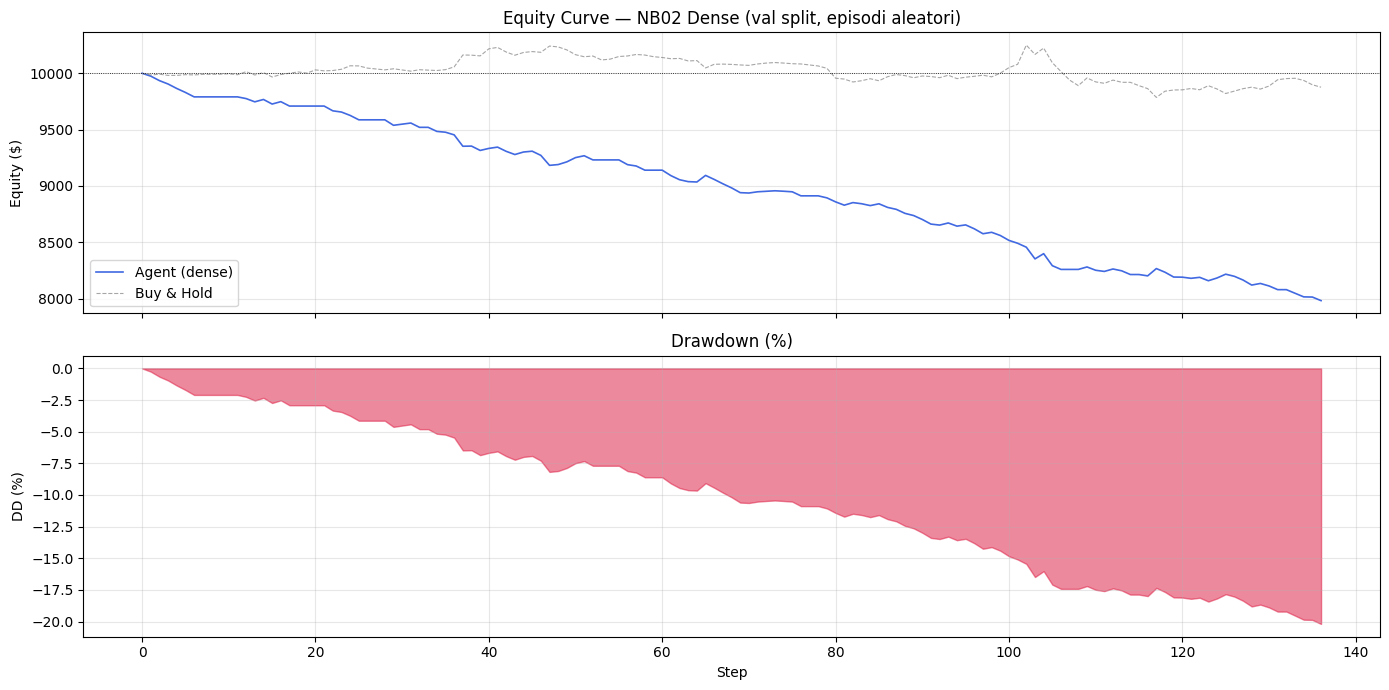

Guardat: results_dense\02_environment_dense_tests\nb02_dense_equity_curve.png

Distribució d'accions: {'HOLD': 36, 'LONG': 26, 'SHORT': 34, 'CLOSE': 40}


In [55]:
# =============================================================================
# CEL·LA 32 — VISUALITZACIONS: equity curve (dense rewards)
# =============================================================================

rng_vis = np.random.default_rng(SEED + 999)
env_vis = _make_env_dense(df_val)
obs, info = env_vis.reset(seed=int(rng_vis.integers(0, 1_000_000)))

equities = [info['equity']]
prices   = [info['current_price']]
actions  = []
done     = False

while not done:
    action = env_vis.action_space.sample()
    obs, rew, term, trunc, info = env_vis.step(action)
    done = term or trunc
    equities.append(info['equity'])
    prices.append(info['current_price'])
    actions.append(action)

eq_arr = np.array(equities)
pr_arr = np.array(prices)

print(f"Episodi: {len(actions)} steps")
print(f"Retorn:  {(eq_arr[-1]/eq_arr[0] - 1)*100:+.2f}%")
print(f"Sharpe:  {compute_sharpe(equities):+.4f}")
print(f"MaxDD:   {compute_max_drawdown(equities):.2f}%")
print()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(eq_arr, color='royalblue', lw=1.2, label='Agent (dense)')
if len(pr_arr) > 0:
    bh = INITIAL_BALANCE * pr_arr / pr_arr[0]
    axes[0].plot(bh, color='gray', lw=0.8, linestyle='--', alpha=0.7, label='Buy & Hold')
axes[0].axhline(INITIAL_BALANCE, color='black', lw=0.6, linestyle=':')
axes[0].set_title('Equity Curve — NB02 Dense (val split, episodi aleatori)')
axes[0].set_ylabel('Equity ($)')
axes[0].legend()
axes[0].grid(alpha=0.3)

run = np.maximum.accumulate(eq_arr)
dd  = (eq_arr - run) / (run + 1e-10) * 100
axes[1].fill_between(range(len(dd)), dd, 0, color='crimson', alpha=0.5)
axes[1].set_title('Drawdown (%)')
axes[1].set_ylabel('DD (%)')
axes[1].set_xlabel('Step')
axes[1].grid(alpha=0.3)

plt.tight_layout()
save_p = RESULTS_DIR / "nb02_dense_equity_curve.png"
plt.savefig(save_p, dpi=120, bbox_inches='tight')
plt.show()
print(f"Guardat: {save_p}")

action_names = {0: 'HOLD', 1: 'LONG', 2: 'SHORT', 3: 'CLOSE'}
counts = {name: actions.count(k) for k, name in action_names.items()}
print(f"\nDistribució d'accions: {counts}")

---
## Resum

**NB02 completat** — `CryptoMarketEnv` validat amb **dense rewards** sobre dades reals BTC (Kraken 60m).

| Test | Descripció | Resultat |
|------|-----------|----------|
| 1 | Espais (obs/action shape, info keys) | PASS |
| 2 | check_env Gymnasium | PASS |
| 3 | HOLD en FLAT (equity invariant, reward=hold_penalty) | PASS |
| 4 | GO_LONG + HOLD + CLOSE (dense: reward=r_pnl durant HOLD, r_pnl+r_realize al CLOSE) | PASS |
| 5 | GO_SHORT + CLOSE (dense: reward=r_pnl durant HOLD, r_pnl+r_realize al CLOSE) | PASS |
| 6 | Transicions completes FLAT↔LONG↔SHORT | PASS |
| 7 | Fees taker + margin_opening | PASS |
| 8 | Rollover fees (> STEPS_PER_4H passos) | PASS |
| 9 | Components de recompensa (dense reward_info) | PASS |
| 10 | Consistència equity tracking | PASS |
| 11 | **Dense PnL** — reward=r_pnl durant posició, r_pnl+r_realize al CLOSE | PASS |
| 12 | **Hold penalty** — només en FLAT; en posició reward=r_pnl (no hold_penalty) | PASS |
| 13 | DD penalty — terminació per drawdown | PASS |
| 14 | **r_realize** — bonus PnL consolidat al CLOSE (reward = r_pnl + r_realize) | PASS |
| 15 | Smoke test 20 episodis | PASS |
| 16 | Multi-split (train/val/test) | PASS |
| 17 | Edge case prop del final del dataset | PASS |
| 18 | Fee Curriculum (fee_factor) | PASS |
| 19 | **open_position_penalty** — truncació amb posició oberta | PASS |
| 20 | **Multi-trade** — 7 trades mixtes (LONG/SHORT, holds variats), reward=r_pnl+r_realize | PASS |

### Semàntica de recompensa dense (`CryptoMarketEnv`, W_PNL=1.0):

| Situació | Reward |
|----------|--------|
| HOLD en FLAT | `hold_penalty` (-0.00002) |
| GO_LONG / GO_SHORT | `r_pnl` (log-return incloent fee d'obertura) |
| HOLD en LONG/SHORT | `r_pnl` (log-return per-step del portafoli) |
| CLOSE | `r_pnl` (impacte fee tancament) + `r_realize` (bonus PnL consolidat) |
| Terminació per DD | reward + `dd_penalty` (-50) |
| Truncació amb posició oberta | reward + `open_position_penalty` (-5) |

**Nota sobre `r_hold`**: la penalització s'aplica **exclusivament** quan l'agent fa HOLD estant en FLAT (no al pas de CLOSE, no en posició oberta). Implementat amb la bandera `in_idle_flat` a `step()`.

### Comparació dense vs sparse:

- **Dense** (`CryptoMarketEnv`): feedback per-step via `r_pnl` → crèdit assignat a cada vela
- **Sparse** (`CryptoMarketEnvConsolidatedReward`): reward=0 durant HOLD en posició → crèdit holístic al CLOSE

### Hipòtesi dense rewards:

El feedback granular per-step pot accelerar l'aprenentatge quan l'agent rep senyal de seguida de cada moviment de preu. El risc és el soroll: l'agent pot intentar optimitzar retorns intra-trade (overfit a soroll) en comptes de la qualitat del trade complet. Comparat amb el sparse, el credit assignment és immediat però menys estable.

**Següent pas**: Comparar convergència PPO dense vs sparse (NB03).